# Question 2: Classification on Synthetic High-Dimensional Data

In this assignment, we will train a neural network to classify a synthetic dataset. This dataset mimics a higher-dimensional problem (20 features) with informative signals and noise.

In [1]:
import numpy as np
import torch
import random
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Fix Seeds for Reproducibility
# NOTE: do not modify the seed value.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(torch.double)

# Generate Synthetic Data
X, y = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=5,
    n_redundant=2,
    n_classes=3,
    n_clusters_per_class=1,
    class_sep=2.0,
    flip_y=0.01,
    random_state=SEED
)

# Preprocessing: Standardize Features and Split Data
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

print(f"Training Data Shape: {X_train.shape}")
print(f"Test Data Shape: {X_test.shape}")

Training Data Shape: (1600, 20)
Test Data Shape: (400, 20)


## Data Visualization
Since the data is 20-dimensional, we cannot plot it directly. We first visualize the first two dimensions to get an intuition about the data distribution. After that, we use t-SNE to project the data into a 2D space to show the clusters more clearly.

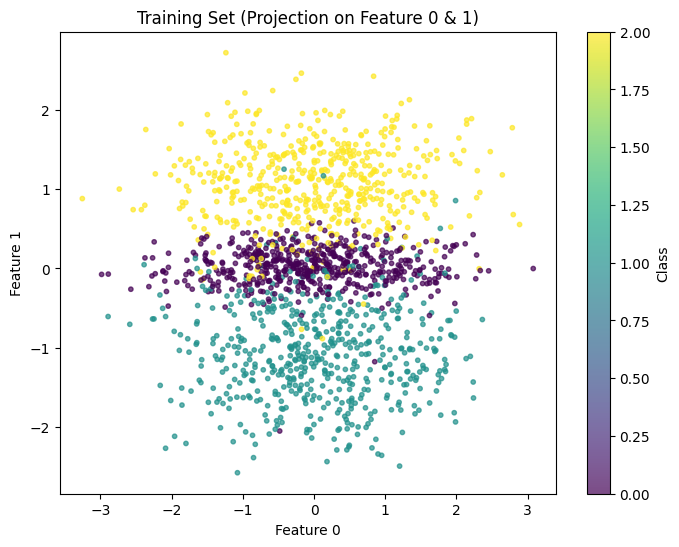

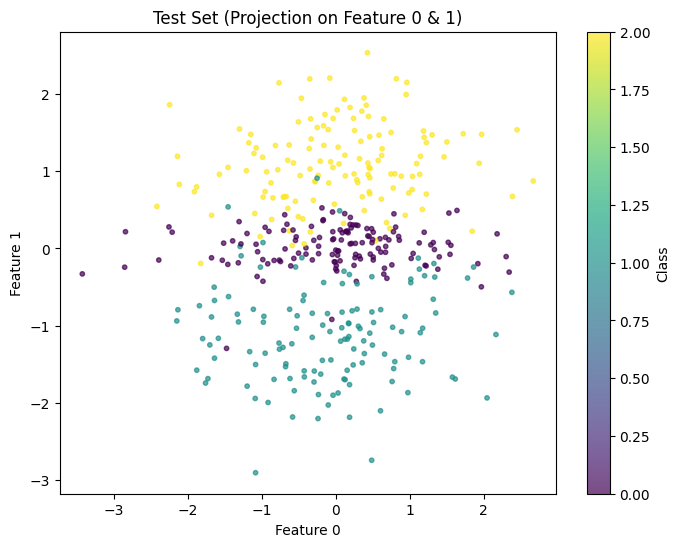

Running t-SNE on Training Set...


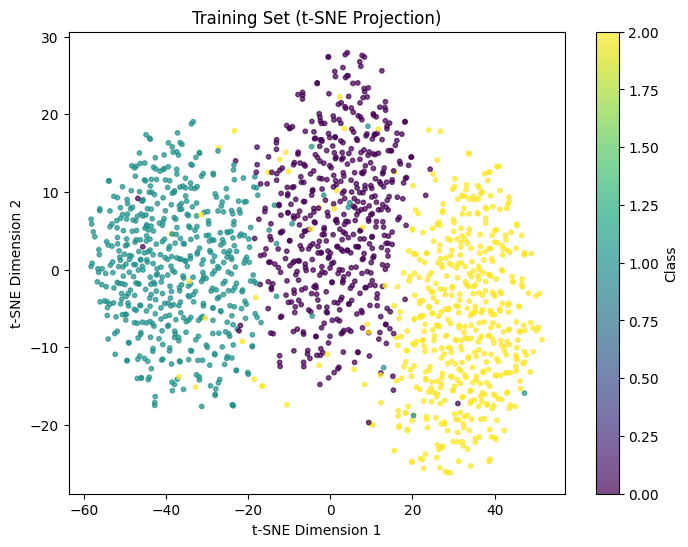

Running t-SNE on Test Set...


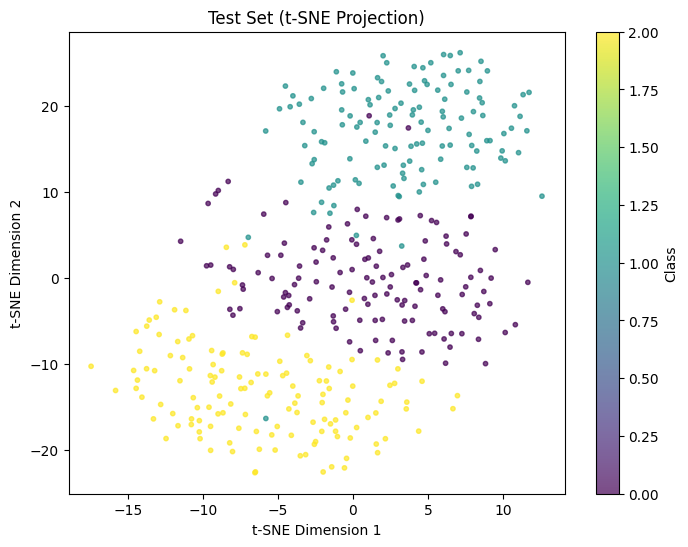

In [2]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Helper function to plot the data (First 2 dimensions only)
def plotDataSet(X, y, name):
    plt.figure(figsize=(8, 6))
    plt.title(f"{name} (Projection on Feature 0 & 1)")
    plt.xlabel('Feature 0')
    plt.ylabel('Feature 1')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=10, alpha=0.7)
    plt.colorbar(label='Class')
    plt.show()

plotDataSet(X_train, y_train, 'Training Set')
plotDataSet(X_test, y_test, 'Test Set')


def plotDataSet_tSNE(X, y, name):
    print(f"Running t-SNE on {name}...")

    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=SEED)
    X_embedded = tsne.fit_transform(X)


    plt.figure(figsize=(8, 6))
    plt.title(f"{name} (t-SNE Projection)")
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y, cmap='viridis', s=10, alpha=0.7)
    plt.colorbar(label='Class')
    plt.show()

plotDataSet_tSNE(X_train, y_train, 'Training Set')
plotDataSet_tSNE(X_test, y_test, 'Test Set')

We can see from the visualizations that the classes are roughly Gaussian distributed, which is relatively easy for a classifier to learn.

## Define Network Architecture (2-Layer)

First, you are asked to define a shallow network with two layers.

In [3]:
import torch.nn as nn

class TwoLayersNet(nn.Module):
    def __init__(self, num_hid):
        super(TwoLayersNet, self).__init__()
        # TODO: Add two linear layers. The dimension of the hidden units should be defined
        #       by the variable num_hid. Make sure that the input and output are 20 and 3 dimensional, respectively.
        self.fc_layer_1 = nn.Linear(20, num_hid)
        self.fc_layer_2 = nn.Linear(num_hid, 3)

    def forward(self, x):
        # TODO: Complete the forward pass.
        hidden_s1 = self.fc_layer_1(x)
        # Use a tanh a activation function
        layer_1 = torch.tanh(hidden_s1)
        # Output raw logits
        output = self.fc_layer_2(layer_1)
        return output

## Training & Test Loops

Now we define the training and test loops. Don't worry if you don't understand all the code. You will understand it once you saw it in the context with the rest of the code.

In [4]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    train_loss, accuracy = 0, 0

    model.train() # Set model to train mode
    for batch, (X, y) in enumerate(dataloader):
        # TODO: Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        train_loss += loss.item()
        # Multi-class accuracy: argmax(1)
        accuracy += (pred.argmax(1) == y).sum().item()

        # TODO: Write the code for backpropagation and optimization step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= num_batches
    accuracy /= size
    print(f"Training: Accuracy: {(100*accuracy):>0.1f}%, Avg loss: {train_loss:>8f}")
    return train_loss, accuracy

def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, accuracy = 0, 0

    model.eval() # Set model to eval mode
    with torch.no_grad():
        for X, y in dataloader:
            # TODO: Compute prediction, test_loss and correct. Hint: To access a variable of a torch scalar object you can use .item().
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            accuracy += (pred.argmax(1) == y).sum().item()

    test_loss /= num_batches
    accuracy /= size
    print(f"Testing: Accuracy: {(100*accuracy):>0.1f}%, Avg loss: {test_loss:>8f}")
    return test_loss,accuracy

## Convert to PyTorch DataLoaders

So far, our datasets are stored as numpy type. To be able to used them with PyTorch, we have to convert them to PyTorch data types.

In [5]:
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors
tensor_x_train = torch.from_numpy(X_train)
tensor_y_train = torch.from_numpy(y_train).long() # Labels must be Long for CrossEntropy
tensor_x_test = torch.from_numpy(X_test)
tensor_y_test = torch.from_numpy(y_test).long()

# Create Datasets and DataLoaders
BATCH_SIZE = 64
dataset_train = TensorDataset(tensor_x_train, tensor_y_train)
dataloader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)

# TODO: Do the same for dataset_test and dataloader_test, while set the shuffle to False
dataset_test = TensorDataset(tensor_x_test, tensor_y_test)
dataloader_test = DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False)

## Training Phase

Before we can train the network, we have to create the network with the `num_hid=10`, choose a criterion (loss function) and create an optimizer.

In [6]:
import torch.optim as optim

# TODO: Create a network of type TwoLayersNet (with 10 hidden units)
net = TwoLayersNet(num_hid=10)

# TODO: Use CrossEntropyLoss from PyTorch as criterion
criterion = nn.CrossEntropyLoss()

learning_rate = 0.001

# TODO: In a first step we will use the PyTorch's SGD optimizer with
#       the defined learning rate and a momentum of 0.9.
optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9)

Now we can train the network for 200 epochs.

In [7]:
epochs = 200
print("Start Training...")
for t in range(epochs):
    train_loss, train_acc = train_loop(dataloader_train, net, criterion, optimizer)
    if t % 20 == 0 and t != 0:

        print(f"===============================================\nEpoch {t+1}:")
        test_loss, test_acc = test_loop(dataloader_test, net, criterion)
        print(f"===============================================")

print(f"\nFinal Evaluation (2-Layer Net): Test Accuracy: {test_acc*100:.1f}% | Test Loss: {test_loss:.4f}")

Start Training...
Training: Accuracy: 56.7%, Avg loss: 1.001316
Training: Accuracy: 64.6%, Avg loss: 0.923234
Training: Accuracy: 70.6%, Avg loss: 0.845810
Training: Accuracy: 74.1%, Avg loss: 0.777574
Training: Accuracy: 77.4%, Avg loss: 0.718484
Training: Accuracy: 80.2%, Avg loss: 0.665903
Training: Accuracy: 82.2%, Avg loss: 0.619740
Training: Accuracy: 84.7%, Avg loss: 0.578332
Training: Accuracy: 86.4%, Avg loss: 0.541262
Training: Accuracy: 87.9%, Avg loss: 0.507205
Training: Accuracy: 89.1%, Avg loss: 0.476444
Training: Accuracy: 90.2%, Avg loss: 0.448102
Training: Accuracy: 91.4%, Avg loss: 0.422028
Training: Accuracy: 92.4%, Avg loss: 0.398095
Training: Accuracy: 93.7%, Avg loss: 0.376048
Training: Accuracy: 94.4%, Avg loss: 0.355958
Training: Accuracy: 95.1%, Avg loss: 0.337259
Training: Accuracy: 95.3%, Avg loss: 0.320469
Training: Accuracy: 95.8%, Avg loss: 0.304925
Training: Accuracy: 96.2%, Avg loss: 0.290718
Training: Accuracy: 96.4%, Avg loss: 0.277564
Epoch 21:
Testin

The accuracy on the test set should have converged to above 95%. This indicates that the model is able to generalize well to unseen data and is not just memorizing the training examples.

## Predictions Visualization

Now we can visualize the predictions of the model on the test set. This will help us understand how well the model is performing and whether it is making accurate predictions.

Running t-SNE on Prediction on Test Set...


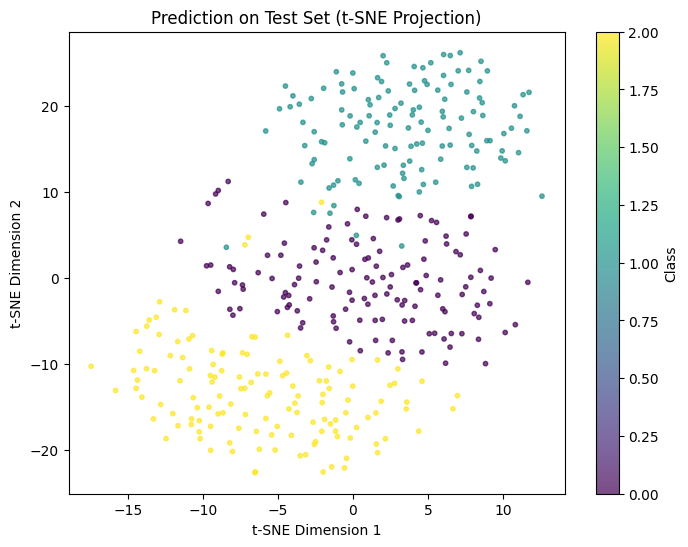

Running t-SNE on Ground Truth on Test Set...


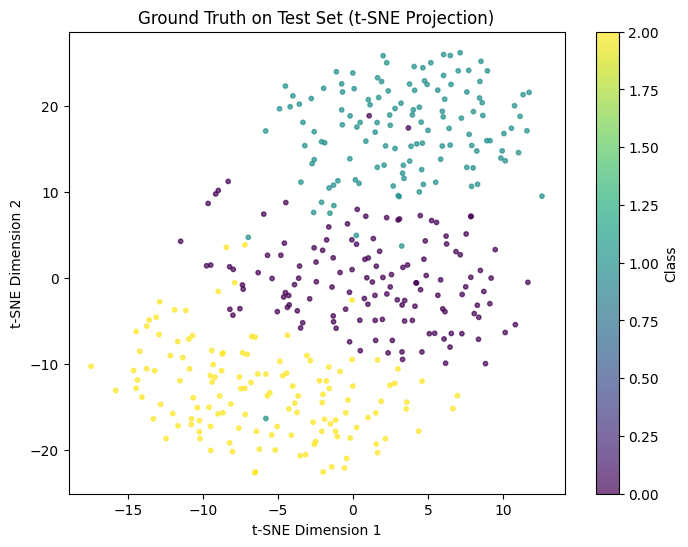

In [8]:
y_pred = []
net.eval()
with torch.no_grad():
    for Xt, yt in zip(tensor_x_test, tensor_y_test):
        pred = net(Xt.unsqueeze(0)) # Add batch dimension
        y_pred.append(pred.argmax(1).item())

y_pred = np.array(y_pred)
plotDataSet_tSNE(X_test, y_pred, 'Prediction on Test Set')
plotDataSet_tSNE(X_test, tensor_y_test.numpy(), 'Ground Truth on Test Set')

# Harder Dataset

Now we can create a harder dataset with more complex decision boundaries. This is to evaluate the capacity of our model to learn more intricate patterns.

Training Data Shape: (1600, 20)
Test Data Shape: (400, 20)


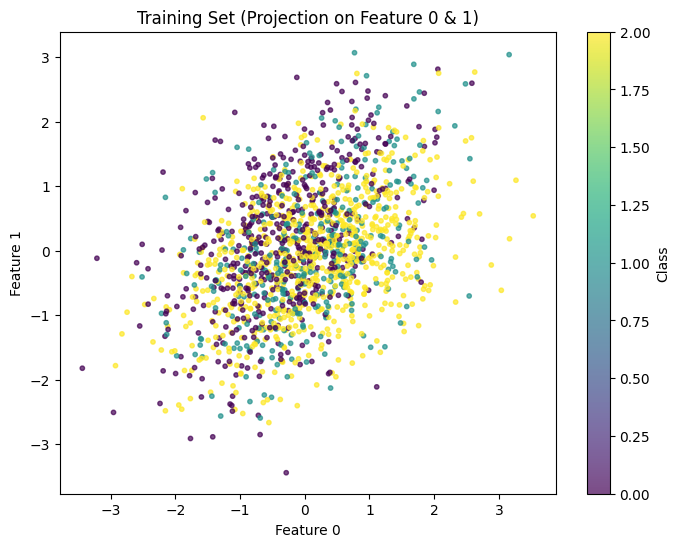

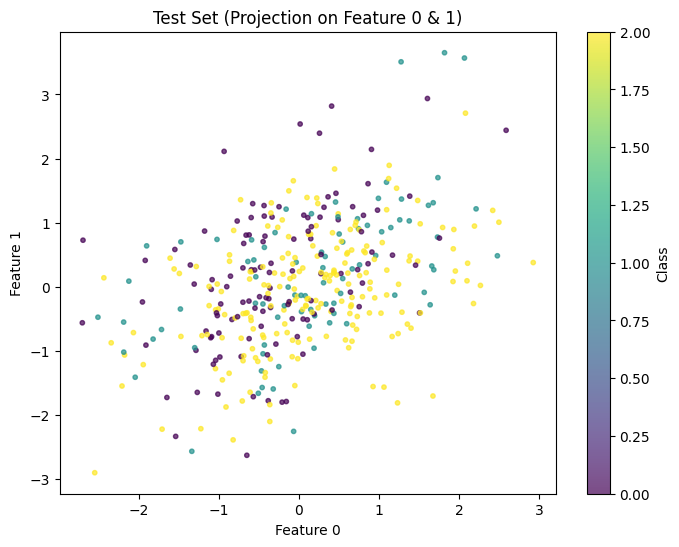

Running t-SNE on Training Set...


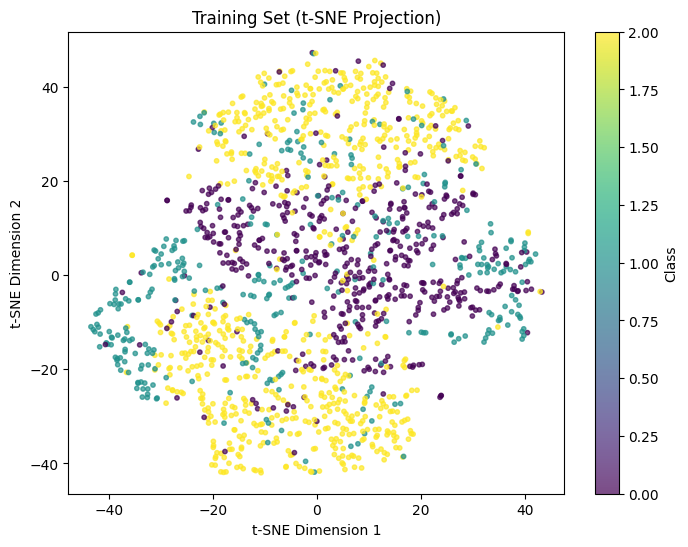

Running t-SNE on Test Set...


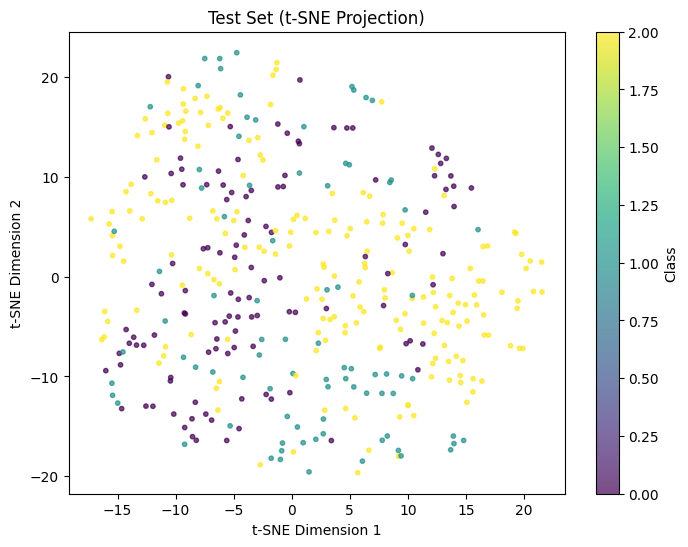

In [9]:
# Generate Synthetic Data
X, y = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=10,
    n_redundant=10,
    n_classes=3,
    n_clusters_per_class=2,
    class_sep=0.9,
    flip_y=0.10,
    weights=[0.3, 0.2, 0.5],
    random_state=SEED
)

# Preprocessing: Standardize Features and Split Data
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

print(f"Training Data Shape: {X_train.shape}")
print(f"Test Data Shape: {X_test.shape}")

plotDataSet(X_train, y_train, 'Training Set')
plotDataSet(X_test, y_test, 'Test Set')

plotDataSet_tSNE(X_train, y_train, 'Training Set')
plotDataSet_tSNE(X_test, y_test, 'Test Set')

We can see from the data distribution that the classes are not perfectly separable, which makes the classification task more challenging. Let's see how our model performs on this harder dataset.

In this case, we keep the same model architecture and training procedure but on the more complex dataset.

In [10]:
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors
tensor_x_train = torch.from_numpy(X_train)
tensor_y_train = torch.from_numpy(y_train).long() # Labels must be Long for CrossEntropy
tensor_x_test = torch.from_numpy(X_test)
tensor_y_test = torch.from_numpy(y_test).long()

# Create Datasets and DataLoaders
BATCH_SIZE = 64
dataset_train = TensorDataset(tensor_x_train, tensor_y_train)
dataloader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)

# TODO: Do the same for dataset_test and dataloader_test, while set the shuffle to False
dataset_test = TensorDataset(tensor_x_test, tensor_y_test)
dataloader_test = DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False)

In [11]:
# TODO: Create a network of type TwoLayersNet (with 10 hidden units), criterion and optimizer same as before
net = TwoLayersNet(num_hid=10)

criterion = nn.CrossEntropyLoss()

learning_rate = 0.001

optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9)

epochs = 200
print("Start Training...")
for t in range(epochs):
    train_loss, train_acc = train_loop(dataloader_train, net, criterion, optimizer)
    if t % 20 == 0 and t != 0:

        print(f"===============================================\nEpoch {t+1}:")
        test_loss, test_acc = test_loop(dataloader_test, net, criterion)
        print(f"===============================================")

print(f"\nFinal Evaluation (2-Layer Net): Test Accuracy: {test_acc*100:.1f}% | Test Loss: {test_loss:.4f}")

Start Training...
Training: Accuracy: 35.9%, Avg loss: 1.107969
Training: Accuracy: 37.6%, Avg loss: 1.083751
Training: Accuracy: 42.2%, Avg loss: 1.059225
Training: Accuracy: 46.2%, Avg loss: 1.038339
Training: Accuracy: 49.9%, Avg loss: 1.019447
Training: Accuracy: 52.8%, Avg loss: 1.002961
Training: Accuracy: 55.1%, Avg loss: 0.988212
Training: Accuracy: 56.1%, Avg loss: 0.975008
Training: Accuracy: 56.9%, Avg loss: 0.962994
Training: Accuracy: 57.8%, Avg loss: 0.952005
Training: Accuracy: 58.5%, Avg loss: 0.942219
Training: Accuracy: 59.3%, Avg loss: 0.933034
Training: Accuracy: 60.0%, Avg loss: 0.924755
Training: Accuracy: 60.3%, Avg loss: 0.917394
Training: Accuracy: 60.8%, Avg loss: 0.910023
Training: Accuracy: 61.1%, Avg loss: 0.903787
Training: Accuracy: 61.6%, Avg loss: 0.897823
Training: Accuracy: 62.0%, Avg loss: 0.892243
Training: Accuracy: 62.1%, Avg loss: 0.887158
Training: Accuracy: 62.2%, Avg loss: 0.882548
Training: Accuracy: 62.3%, Avg loss: 0.878245
Epoch 21:
Testin

The accuracy on the test set now should be lower than 75% since the classes are not perfectly separable, making the classification task more challenging. It means that we need a model with more capacity to improve performance.

# 2-Layer Network with more hidden dimensions

To increase the model capacity, we will modify the neural network architecture by adding more hidden dimensions to the existing layers. We can set `num_hid=50` and see how it affects the model performance.

In [12]:
# TODO: Create a network of type TwoLayersNet (with 100 hidden units), criterion and optimizer
net = TwoLayersNet(num_hid=100)

criterion = nn.CrossEntropyLoss()

learning_rate = 0.001

optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9)

epochs = 200
print("Start Training...")
for t in range(epochs):
    train_loss, train_acc = train_loop(dataloader_train, net, criterion, optimizer)
    if t % 20 == 0 and t != 0:

        print(f"===============================================\nEpoch {t+1}:")
        test_loss, test_acc = test_loop(dataloader_test, net, criterion)
        print(f"===============================================")

print(f"\nFinal Evaluation (2-Layer Net): Test Accuracy: {test_acc*100:.1f}% | Test Loss: {test_loss:.4f}")

Start Training...
Training: Accuracy: 42.7%, Avg loss: 1.067555
Training: Accuracy: 51.1%, Avg loss: 1.011489
Training: Accuracy: 55.7%, Avg loss: 0.967715
Training: Accuracy: 58.4%, Avg loss: 0.936116
Training: Accuracy: 59.9%, Avg loss: 0.913983
Training: Accuracy: 60.7%, Avg loss: 0.896799
Training: Accuracy: 61.5%, Avg loss: 0.883912
Training: Accuracy: 61.8%, Avg loss: 0.873296
Training: Accuracy: 62.5%, Avg loss: 0.865019
Training: Accuracy: 62.8%, Avg loss: 0.858017
Training: Accuracy: 62.9%, Avg loss: 0.852178
Training: Accuracy: 63.2%, Avg loss: 0.847006
Training: Accuracy: 63.3%, Avg loss: 0.842912
Training: Accuracy: 63.6%, Avg loss: 0.839561
Training: Accuracy: 64.0%, Avg loss: 0.836386
Training: Accuracy: 64.1%, Avg loss: 0.833894
Training: Accuracy: 64.1%, Avg loss: 0.831317
Training: Accuracy: 64.6%, Avg loss: 0.829194
Training: Accuracy: 64.6%, Avg loss: 0.827233
Training: Accuracy: 65.0%, Avg loss: 0.825708
Training: Accuracy: 65.2%, Avg loss: 0.823944
Epoch 21:
Testin

In is seen that increasing the hidden dimensions to 100 improves the model's capacity to learn complex patterns, leading to better performance on the test set.

## 3-Layer Network Extension

We can further add 1 more hidden layer to the network and see how it affects the performance.

In [13]:
class ThreeLayersNet(nn.Module):
    def __init__(self, num_hid):
        super(ThreeLayersNet, self).__init__()
        # TODO: Add three linear layers. The dimension of the hidden units should be defined
        #       by the variable num_hid. Make sure that the input and output are 20 and 3 dimensional, respectively.
        self.fc_layer_1 = nn.Linear(20, num_hid)
        self.fc_layer_2 = nn.Linear(num_hid, num_hid)
        self.fc_layer_3 = nn.Linear(num_hid, 3)

    def forward(self, x):
        # TODO: Complete the forward pass.
        hidden_s1 = self.fc_layer_1(x)
        # Use a tanh activation function
        layer_1 = torch.tanh(hidden_s1)

        hidden_s2 = self.fc_layer_2(layer_1)
        # Use a tanh activation function
        layer_2 = torch.tanh(hidden_s2)

        # Output raw logits
        output = self.fc_layer_3(layer_2)
        return output

In [14]:
# TODO: Create a network of type ThreeLayersNet (with 100 hidden units)
net = ThreeLayersNet(num_hid=100)

# TODO: Use CrossEntropyLoss from PyTorch as criterion
criterion = nn.CrossEntropyLoss()

learning_rate = 0.001

# TODO: In a first step we will use the PyTorch's SGD optimizer with
#       the defined learning rate and a momentum of 0.9.
optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9)

epochs = 200
print("Start Training...")
for t in range(epochs):
    train_loss, train_acc = train_loop(dataloader_train, net, criterion, optimizer)
    if t % 20 == 0 and t != 0:

        print(f"===============================================\nEpoch {t+1}:")
        test_loss, test_acc = test_loop(dataloader_test, net, criterion)
        print(f"===============================================")

print(f"\nFinal Evaluation (3-Layer Net): Test Accuracy: {test_acc*100:.1f}% | Test Loss: {test_loss:.4f}")

Start Training...
Training: Accuracy: 47.9%, Avg loss: 1.060062
Training: Accuracy: 53.6%, Avg loss: 1.021702
Training: Accuracy: 57.1%, Avg loss: 0.988171
Training: Accuracy: 58.4%, Avg loss: 0.961781
Training: Accuracy: 60.6%, Avg loss: 0.940768
Training: Accuracy: 61.3%, Avg loss: 0.923976
Training: Accuracy: 61.7%, Avg loss: 0.909117
Training: Accuracy: 62.1%, Avg loss: 0.896874
Training: Accuracy: 62.4%, Avg loss: 0.885860
Training: Accuracy: 62.7%, Avg loss: 0.876966
Training: Accuracy: 63.0%, Avg loss: 0.868691
Training: Accuracy: 63.2%, Avg loss: 0.861862
Training: Accuracy: 63.7%, Avg loss: 0.855631
Training: Accuracy: 63.4%, Avg loss: 0.850123
Training: Accuracy: 63.7%, Avg loss: 0.845610
Training: Accuracy: 63.7%, Avg loss: 0.841374
Training: Accuracy: 64.1%, Avg loss: 0.837926
Training: Accuracy: 64.1%, Avg loss: 0.834648
Training: Accuracy: 64.2%, Avg loss: 0.831885
Training: Accuracy: 64.6%, Avg loss: 0.829401
Training: Accuracy: 64.6%, Avg loss: 0.826982
Epoch 21:
Testin

You should be able to see that the accuracy on the test set is still bouncing around (between 75% and 80%) and therefore did not yet converged. Let's train the network a bit more and see if it converges.

In [15]:
epochs = 300
print("Start Training...")
for t in range(epochs):
    train_loss, train_acc = train_loop(dataloader_train, net, criterion, optimizer)
    if t % 20 == 0 and t != 0:

        print(f"===============================================\nEpoch {t+1}:")
        test_loss, test_acc = test_loop(dataloader_test, net, criterion)
        print(f"===============================================")

print(f"\nFinal Evaluation (3-Layer Net): Test Accuracy: {test_acc*100:.1f}% | Test Loss: {test_loss:.4f}")

Start Training...
Training: Accuracy: 81.2%, Avg loss: 0.543272
Training: Accuracy: 80.9%, Avg loss: 0.542913
Training: Accuracy: 81.2%, Avg loss: 0.541399
Training: Accuracy: 81.2%, Avg loss: 0.539549
Training: Accuracy: 81.1%, Avg loss: 0.538577
Training: Accuracy: 81.2%, Avg loss: 0.538037
Training: Accuracy: 81.1%, Avg loss: 0.535601
Training: Accuracy: 81.4%, Avg loss: 0.535196
Training: Accuracy: 81.6%, Avg loss: 0.533716
Training: Accuracy: 81.5%, Avg loss: 0.533268
Training: Accuracy: 81.8%, Avg loss: 0.531619
Training: Accuracy: 81.6%, Avg loss: 0.530201
Training: Accuracy: 81.9%, Avg loss: 0.529206
Training: Accuracy: 81.6%, Avg loss: 0.528255
Training: Accuracy: 81.7%, Avg loss: 0.526551
Training: Accuracy: 81.6%, Avg loss: 0.525499
Training: Accuracy: 81.9%, Avg loss: 0.524897
Training: Accuracy: 82.1%, Avg loss: 0.523444
Training: Accuracy: 81.9%, Avg loss: 0.522620
Training: Accuracy: 81.6%, Avg loss: 0.521972
Training: Accuracy: 81.9%, Avg loss: 0.520348
Epoch 21:
Testin

We will see the model performance improves further with longer training, indicating that the deeper network can better capture the complex patterns in the data.

# Open Question (not graded)
Try more modifications to the network architecture (e.g., more layers, different topologies, etc.) to see if you can further improve the performance on the harder dataset.
NOTE: Please limit the number of learnable parameters to be under 20,000 and keep the epochs as 200.

In [52]:
import torch.nn.functional as F


class CustomNet(nn.Module):
    def __init__(self, num_hid=100):
        super(CustomNet, self).__init__()
        self.fc_layer_1 = nn.Linear(20, num_hid)
        self.bn1 = nn.BatchNorm1d(num_hid)
        self.fc_layer_2 = nn.Linear(num_hid, num_hid)
        self.bn2 = nn.BatchNorm1d(num_hid)
        self.fc_layer_3 = nn.Linear(num_hid, 3)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        hidden_s1 = self.fc_layer_1(x)
        layer_1 = torch.relu(self.bn1(hidden_s1))
        layer_1 = self.dropout(layer_1)

        hidden_s2 = self.fc_layer_2(layer_1)
        layer_2 = torch.relu(self.bn2(hidden_s2))
        layer_2 = self.dropout(layer_2)

        output = self.fc_layer_3(layer_2)
        return output

net = CustomNet(num_hid=100)
print(f"Total number of learnable parameters: {sum(p.numel() for p in net.parameters() if p.requires_grad)}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)


Total number of learnable parameters: 12903


In [54]:
# TODO: Use CrossEntropyLoss from PyTorch as criterion
criterion = nn.CrossEntropyLoss()

learning_rate = 0.001

# TODO: In a first step we will use the PyTorch's SGD optimizer with
#       the defined learning rate and a momentum of 0.9.
optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9)

epochs = 200
print("Start Training...")
for t in range(epochs):
    train_loss, train_acc = train_loop(dataloader_train, net, criterion, optimizer)
    if t % 20 == 0 and t != 0:

        print(f"===============================================\nEpoch {t+1}:")
        test_loss, test_acc = test_loop(dataloader_test, net, criterion)
        print(f"===============================================")

print(f"\nFinal Evaluation: Test Accuracy: {test_acc*100:.1f}% | Test Loss: {test_loss:.4f}")

Start Training...
Training: Accuracy: 82.4%, Avg loss: 0.475873
Training: Accuracy: 84.1%, Avg loss: 0.456473
Training: Accuracy: 83.9%, Avg loss: 0.474424
Training: Accuracy: 82.5%, Avg loss: 0.487816
Training: Accuracy: 82.6%, Avg loss: 0.484042
Training: Accuracy: 85.1%, Avg loss: 0.437370
Training: Accuracy: 83.1%, Avg loss: 0.467682
Training: Accuracy: 83.1%, Avg loss: 0.474535
Training: Accuracy: 82.0%, Avg loss: 0.483960
Training: Accuracy: 82.2%, Avg loss: 0.482796
Training: Accuracy: 83.2%, Avg loss: 0.478364
Training: Accuracy: 82.4%, Avg loss: 0.504659
Training: Accuracy: 82.6%, Avg loss: 0.469071
Training: Accuracy: 83.1%, Avg loss: 0.470548
Training: Accuracy: 84.2%, Avg loss: 0.463834
Training: Accuracy: 83.2%, Avg loss: 0.457617
Training: Accuracy: 83.5%, Avg loss: 0.461422
Training: Accuracy: 83.1%, Avg loss: 0.488716
Training: Accuracy: 82.1%, Avg loss: 0.476455
Training: Accuracy: 83.2%, Avg loss: 0.481097
Training: Accuracy: 83.4%, Avg loss: 0.484519
Epoch 21:
Testin